Dataset loaded successfully!

First 5 Records:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Last 5 Records:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

Dataset Shape:
(200, 5)

Data Types:
CustomerID                 int64
G

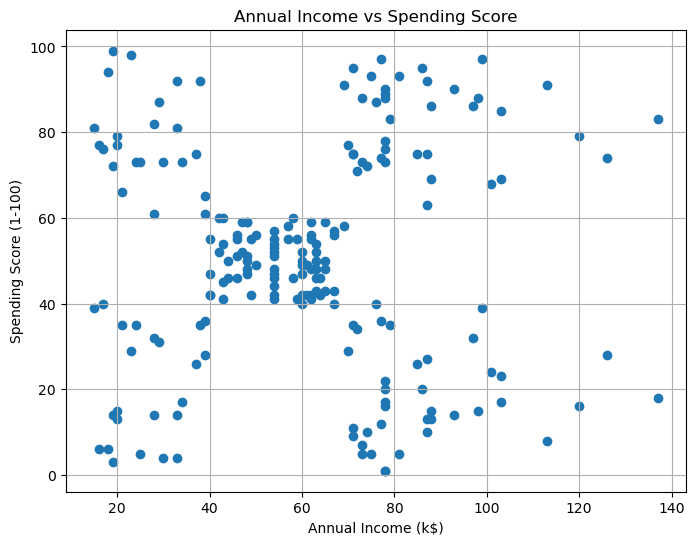

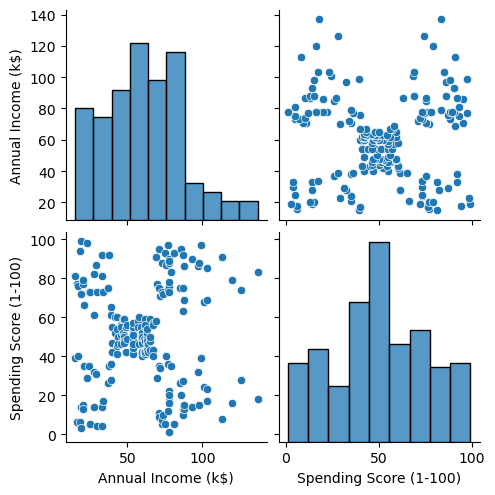


Standardized Data:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

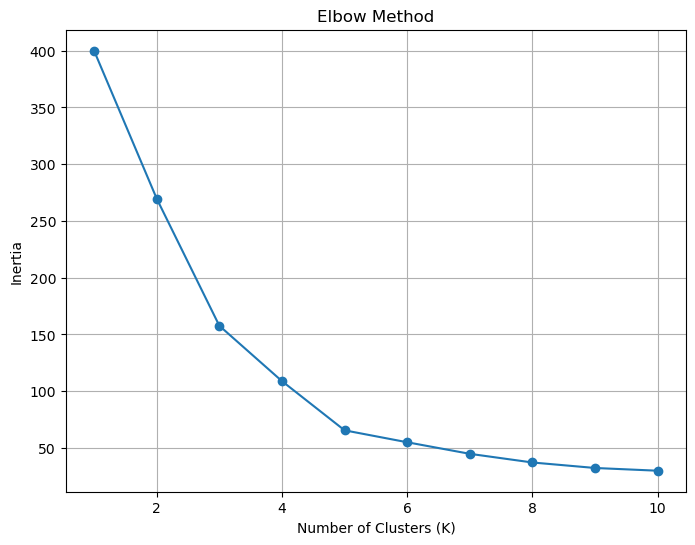


Dataset with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Clustered dataset saved as:
Mall_Customers_Clustered.csv

Cluster Centroids:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


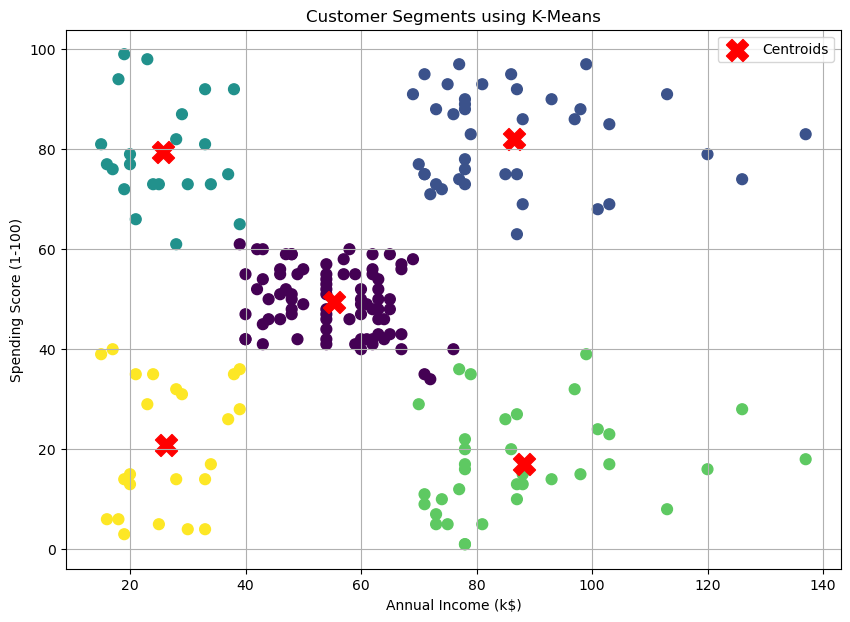


Centroid Coordinates:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Number of Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Average Income and Spending Score:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

FINAL CLUSTER ANALYSIS

Cluster: 0
Number of Customers: 81
Average Annual Income: 55.3
Average Spend

In [1]:
# ==========================================================
# EX7: MODEL PLANNING AND BUILDING - CLUSTERING
# K-MEANS CUSTOMER SEGMENTATION
# ==========================================================


# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ==========================================================
# 2. LOAD KAGGLE DATASET
# ==========================================================

# Change this path according to where you saved the file

df = pd.read_csv(
    r"C:\Users\REC\Downloads\archive (2)\Mall_Customers.csv"
)

print("Dataset loaded successfully!")


# ==========================================================
# 3. DISPLAY FIRST AND LAST FIVE RECORDS
# ==========================================================

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())


# ==========================================================
# 4. DATASET SHAPE
# ==========================================================

print("\nDataset Shape:")
print(df.shape)


# ==========================================================
# 5. DATA TYPES
# ==========================================================

print("\nData Types:")
print(df.dtypes)


# ==========================================================
# 6. CHECK MISSING VALUES
# ==========================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================================
# 7. CHECK DUPLICATE RECORDS
# ==========================================================

print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())


# ==========================================================
# 8. SUMMARY STATISTICS
# ==========================================================

print("\nSummary Statistics:")
print(df.describe())


# ==========================================================
# 9. SELECT FEATURES FOR CLUSTERING
# ==========================================================

X = df[
    ["Annual Income (k$)", "Spending Score (1-100)"]
]

print("\nSelected Features:")
print(X.head())


# ==========================================================
# 10. SCATTER PLOT BEFORE CLUSTERING
# ==========================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.grid()
plt.show()


# ==========================================================
# 11. PAIR PLOT
# ==========================================================

sns.pairplot(
    X
)

plt.show()


# ==========================================================
# 12. STANDARDIZATION
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])


# ==========================================================
# 13. ELBOW METHOD
# ==========================================================

inertia = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# Plot Elbow Curve

plt.figure(figsize=(8, 6))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()
plt.show()


# ==========================================================
# 14. TRAIN K-MEANS MODEL
# ==========================================================

# For this dataset, K = 5 is commonly used.

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)


# ==========================================================
# 15. ADD CLUSTER LABELS TO DATASET
# ==========================================================

df["Cluster"] = cluster_labels

print("\nDataset with Cluster Labels:")
print(df.head())


# ==========================================================
# 16. SAVE CLUSTERED DATASET
# ==========================================================

df.to_csv(
    "Mall_Customers_Clustered.csv",
    index=False
)

print("\nClustered dataset saved as:")
print("Mall_Customers_Clustered.csv")


# ==========================================================
# 17. GET CLUSTER CENTROIDS
# ==========================================================

centroids_scaled = kmeans.cluster_centers_

# Convert centroids back to original scale

centroids = scaler.inverse_transform(
    centroids_scaled
)

print("\nCluster Centroids:")
print(centroids)


# ==========================================================
# 18. CLUSTER VISUALIZATION
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=cluster_labels,
    cmap="viridis",
    s=60
)

# Plot centroids

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    c="red",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.legend()
plt.grid()

plt.show()


# ==========================================================
# 19. DISPLAY CENTROID COORDINATES
# ==========================================================

centroid_df = pd.DataFrame(
    centroids,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centroid_df.index.name = "Cluster"

print("\nCentroid Coordinates:")
print(centroid_df)


# ==========================================================
# 20. NUMBER OF CUSTOMERS IN EACH CLUSTER
# ==========================================================

cluster_count = df["Cluster"].value_counts().sort_index()

print("\nNumber of Customers in Each Cluster:")
print(cluster_count)


# ==========================================================
# 21. AVERAGE INCOME AND SPENDING SCORE
# ==========================================================

cluster_analysis = df.groupby("Cluster")[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

print("\nAverage Income and Spending Score:")
print(cluster_analysis)


# ==========================================================
# 22. COMPLETE CLUSTER ANALYSIS
# ==========================================================

print("\n==============================================")
print("FINAL CLUSTER ANALYSIS")
print("==============================================")

for cluster in cluster_analysis.index:

    customers = cluster_count[cluster]

    income = cluster_analysis.loc[
        cluster,
        "Annual Income (k$)"
    ]

    spending = cluster_analysis.loc[
        cluster,
        "Spending Score (1-100)"
    ]

    print("\nCluster:", cluster)
    print("Number of Customers:", customers)
    print("Average Annual Income:", round(income, 2))
    print("Average Spending Score:", round(spending, 2))


# ==========================================================
# 23. MARKETING STRATEGY
# ==========================================================

print("\n==============================================")
print("MARKETING STRATEGIES")
print("==============================================")

for cluster in cluster_analysis.index:

    income = cluster_analysis.loc[
        cluster,
        "Annual Income (k$)"
    ]

    spending = cluster_analysis.loc[
        cluster,
        "Spending Score (1-100)"
    ]

    print("\nCluster", cluster)

    if income < 50 and spending < 50:
        print("Strategy: Budget offers and discounts")

    elif income < 50 and spending >= 50:
        print("Strategy: Attractive offers and loyalty rewards")

    elif income >= 50 and spending < 50:
        print("Strategy: Premium products with targeted promotions")

    else:
        print("Strategy: Premium products, exclusive offers and loyalty programs")